# Code for doing the different clustering methods, as well as data preprocessing

In this file we run the different methods

### DCEC - Deep Convolutional Embedded Clustering
First load the data

In [18]:
#  Loading the data with all 400 features (for 400x400 data) - alternative loading method

from scipy.io import loadmat
import torch
import numpy as np

filepath = "Input Data\\OldAge_combined_run1_400_noZ_clean.mat"
fc_mat = loadmat(filepath)
fc_mat = fc_mat['run1_data']  # Extract the FC2 variable from the loaded .mat file

print(fc_mat.shape)  # Should print (400, 400, N_subjects) for FC2
 # prints (N_subjects, 400, 400) for collected matrices

# fc_mat_inv = np.transpose(fc_mat, (2, 0, 1))  # Transpose to (N_subjects, 400, 400)
# fc_mat_inv = fc_mat_inv[:, None, :, :]  # Add a channel dimension to get (N_subjects, 1, 400, 400)

fc_mat_inv = fc_mat[:, None, :, :]  # Add a channel dimension to get (N_subjects, 1, 400, 400)
print(fc_mat_inv.shape)  # Should print (N_subjects, 1, 400, 400)

X = torch.from_numpy(fc_mat_inv).float()  # Convert to PyTorch tensor
print("Data shape:", X.shape)  # Should print (N_subjects, 1, 400, 400)

# Expected shape is (Batch size, channels, height, width)

(68, 400, 400)
(68, 1, 400, 400)
Data shape: torch.Size([68, 1, 400, 400])


In [13]:
#  Loading the data with all 1000 features (for 1000x1000 data) - alternative loading method

from scipy.io import loadmat
import torch
import numpy as np

filepath = "My_FC_matrices\\FC_Y_run_2.mat"
fc_mat = loadmat(filepath)
print(fc_mat.keys())  # Print the keys to verify the structure of the loaded .mat file
fc_mat = fc_mat['run2_data']  # Extract the FC2 variable from the loaded .mat file

print(fc_mat.shape)  # Should print (1000, 1000, N_subjects) for FC2
 # prints (N_subjects, 1000, 1000) for collected matrices

# fc_mat_inv = np.transpose(fc_mat, (2, 0, 1))  # Transpose to (N_subjects, 1000, 1000)
# fc_mat_inv = fc_mat_inv[:, None, :, :]  # Add a channel dimension to get (N_subjects, 1, 1000, 1000)

fc_mat_inv = fc_mat[:, None, :, :]  # Add a channel dimension to get (N_subjects, 1, 1000, 1000)
print(fc_mat_inv.shape)  # Should print (N_subjects, 1, 1000, 1000)

X = torch.from_numpy(fc_mat_inv).float()  # Convert to PyTorch tensor
print("Data shape:", X.shape)  # Should print (N_subjects, 1, 1000, 1000)

# Expected shape is (Batch size, channels, height, width)

dict_keys(['__header__', '__version__', '__globals__', 'subject_names', 'run2_data', 'fc_matrices'])
(72, 1000, 1000)
(72, 1, 1000, 1000)
Data shape: torch.Size([72, 1, 1000, 1000])


Define the autoencoder specs for the Convolutional Autoencoder (CAE)

In [14]:
# Names
# 400x400
# name = "DCEC_400x400_68_O_subjects_run1"

# 1000x1000
name = "DCEC_1000x1000_71_Y_subjects_run2"

In [15]:
# Config for the DCEC model
from Convolutional_AE import DCECConfig
cfg = DCECConfig(
    name=name,
    n_clusters=2,
    latent_dim=10,
    alpha=1.0,
    gamma=0.1,
    conv_layers_sizes=[1, 32, 64, 128, 256],
    epochs_pretrain=50,
    epochs_dcec=100,
    lr_pretrain=1e-3,
    lr_dcec=1e-3,
    update_interval=9, # Update target distribution every 9 batches, 9 batches in 71 subjects
    tol=4e-2, # 4e-2 = 0.04
    print_interval=10
)


Load the ran model and perform a last clustering

In [ ]:
# Load a model 
from Convolutional_AE import DCEC
import torch
from torch.utils.data import TensorDataset, DataLoader
from data_loader import set_seed

set_seed(42)

model_path = "Models\\model_DCEC_400x400_72_Y_subjects_run2_Cluster_2.pt"

model = DCEC(cfg)
checkpoint = torch.load(model_path)
model.load_state_dict(checkpoint)

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=3, shuffle=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

all_z = []
all_labels = []

with torch.no_grad():
    for (batch,) in dataloader:
        x = batch.to(device)
        x_hat, q, z = model(x)

        labels = torch.argmax(q, dim=1)
        all_z.append(z.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

z_all = np.concatenate(all_z, axis=0)
labels_all = np.concatenate(all_labels, axis=0)

print("z_all shape:", z_all.shape)  # Should be (N_subjects, latent_dim)
print("labels_all shape:", labels_all.shape)  # Should be (N_subjects,)

print("Labels:" , labels_all)

Run the DCEC Model - single run

In [ ]:
# Run the DCEC model once for the 200x200 data
from Convolutional_AE import DCEC, pretrain_cae, initialize_cluster_centers, train_dcec, predict_soft_assignments
from torch.utils.data import TensorDataset, DataLoader

from data_loader import set_seed

# ----------------------------------------------------------
# DCEC - Deep Convolutional Embedded Clustering - Pretraining
# ----------------------------------------------------------
set_seed(42)

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=8, shuffle=False)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DCEC(cfg=cfg).to(device)

pretrain_cae(model, dataloader, device, epochs=cfg.epochs_pretrain, lr=cfg.lr_pretrain, print_interval=cfg.print_interval)
y_pred_initial = initialize_cluster_centers(model, dataloader, device)
print("Early cluster centers initialized.", y_pred_initial)


# Saving the model
torch.save(model.state_dict(), f"Models\\pre_train_model_{cfg.name}.pt") 


In [ ]:
# Run the DCEC model once for the 200x200 data
from Convolutional_AE import DCEC, pretrain_cae, initialize_cluster_centers, train_dcec, predict_soft_assignments
from torch.utils.data import TensorDataset, DataLoader

from data_loader import set_seed

# ----------------------------------------------------------
# DCEC - Deep Convolutional Embedded Clustering - Training
# ----------------------------------------------------------
set_seed(42)

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=8, shuffle=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DCEC(cfg=cfg).to(device)
model.load_state_dict(torch.load(f"Models\\pre_train_model_{cfg.name}.pt"))  # Load the pre-trained model weights


train_dcec(
    model,
    dataloader,
    device,
    gamma=cfg.gamma,
    epochs=cfg.epochs_dcec,
    lr=cfg.lr_dcec,
    update_interval=cfg.update_interval,
    tol=cfg.tol,
    print_interval=cfg.print_interval
    )

q_final, labels = predict_soft_assignments(model, dataloader, device, save=True)
print("Predicted cluster labels:", labels)

# Saving the model
torch.save(model.state_dict(), f"Models\\model_{cfg.name}.pt") 


Evaluate the clustering from a single run

In [ ]:
# Evaluate clustering performance of a single run
from Evaluate_models import evaluate_single_clustering

triu_idx = np.triu_indices(200, k=1)
fc_mat_transp = np.transpose(fc_mat, (2, 0, 1))  # Transpose to (N_subjects, 200, 200)

Features = np.array([
    fc_mat_transp[i][triu_idx] for i in range(fc_mat_transp.shape[0])
]) 
predictions = labels

z = model.z
print("z shape:", z.shape)
print("predictions shape:", predictions.shape)

evaluate_single_clustering(Features, predictions)
evaluate_single_clustering(z, predictions)


In [ ]:
# Plot the model from one run
from Convolutional_AE import DCEC, pretrain_cae, initialize_cluster_centers, train_dcec, predict_soft_assignments
from Evaluate_models import plot_scores, Calculate_clustering_scores_from_folder
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=8, shuffle=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg.n_clusters = 3  # Set the number of clusters to 3 for the latest model
model = DCEC(cfg=cfg).to(device)
model.load_state_dict(torch.load(f"Models/model_DCEC_200x200_clusters_3.pt"))  #


# Code for visualising the clustering results 
from Convolutional_AE import plot_training_history, plot_clustering, plot_reconstruction

plot_reconstruction(model, dataloader, device)
# plot_training_history(model)
plot_clustering(model, dataloader, device)

results = Calculate_clustering_scores_from_folder(models_dir="Clusters", model_prefix="DCEC_200x200_cluster", labels_tag="_labels_predicted_labels_", middle_layer_tag="_middle_layer_predicted_labels_")
plot_scores(results)




Run the DCEC model multiple times

In [ ]:
# Pretraining - multiple
from Convolutional_AE import DCEC, pretrain_cae, initialize_cluster_centers, train_dcec, predict_soft_assignments
from torch.utils.data import TensorDataset, DataLoader
from copy import deepcopy
from data_loader import set_seed

# ----------------------------------------------------------
# DCEC - Deep Convolutional Embedded Clustering - Pretraining
# ----------------------------------------------------------

set_seed(42)  # Set a fixed random seed for reproducibility

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=8, shuffle=False) 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cluster_sizes =  list(range(2, 11)) # Example cluster sizes to evaluate

for n_clusters in cluster_sizes:
    run_cfg = deepcopy(cfg)  # Create a copy of the config for each run
    run_cfg.n_clusters = n_clusters
    
    model = DCEC(cfg=run_cfg).to(device)
    print(f"Running DCEC for cluster {n_clusters} ...")
    pretrain_cae(
        model,
        dataloader,
        device,
        epochs=run_cfg.epochs_pretrain,
        lr=run_cfg.lr_pretrain,
        print_interval=run_cfg.print_interval
    )

    # Saving the model
    torch.save(model.state_dict(), f"Models\\pre_trained_model_{cfg.name}_Cluster_{n_clusters}.pt") 


In [ ]:
# Training - multiple
from Convolutional_AE import DCEC, pretrain_cae, initialize_cluster_centers, train_dcec, predict_soft_assignments
from torch.utils.data import TensorDataset, DataLoader
from copy import deepcopy
from data_loader import set_seed

# ----------------------------------------------------------
# DCEC - Deep Convolutional Embedded Clustering - Training
# ----------------------------------------------------------

set_seed(42)  # Set a fixed random seed for reproducibility

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=8, shuffle=False) # Batch_size 8 gives 9 bacthes for 71 subjects. 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cluster_sizes =  list(range(2, 11)) # Example cluster sizes to evaluate

for n_clusters in cluster_sizes:
    run_cfg = deepcopy(cfg)  # Create a copy of the config for each run
    run_cfg.n_clusters = n_clusters
    
    model = DCEC(cfg=run_cfg).to(device)
    print(f"Running DCEC for cluster {n_clusters} ...")
    
    # Load the pre-trained model weights
    model.load_state_dict(torch.load(f"Models\\pre_trained_model_{cfg.name}_Cluster_{n_clusters}.pt"))  # Load the pre-trained model weights
    y_pred_initial = initialize_cluster_centers(model, dataloader, device)
    print("Early cluster centers initialized.", y_pred_initial)

    train_dcec(
        model,
        dataloader,
        device,
        gamma=run_cfg.gamma,
        epochs=run_cfg.epochs_dcec,
        lr=run_cfg.lr_dcec,
        update_interval=run_cfg.update_interval,
        tol=run_cfg.tol,
        print_interval=run_cfg.print_interval,
        # y_pred_initial=y_pred_initial
    )

    q_final, labels = predict_soft_assignments(model, dataloader, device, save=True)
    print("Predicted cluster labels:", labels)

    # Saving the model
    torch.save(model.state_dict(), f"Models\\model_{cfg.name}_Cluster_{n_clusters}.pt") 


Evaluate the models from multiple cluster amounts

Plot saved to: Figures\Clustering Scores Plot\DCEC_400x400_71_Y_subjects_run1_clustering_scores_plot.png


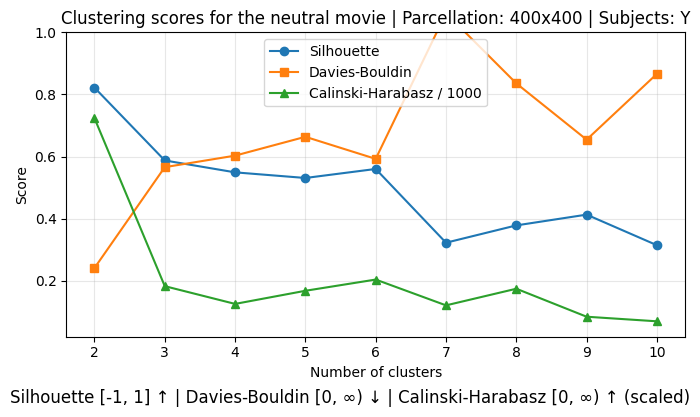

In [31]:
# Print the clustering scores for all the runs 
from Evaluate_models_clean import plot_clustering_scores_sorted

model_dir = "Clusters"
model_prefix = "DCEC_400x400_71_Y_subjects_run1_"
save_path = rf"Figures\Clustering Scores Plot\{model_prefix}clustering_scores_plot.png"

# Silhouett score: Higher is better
# Calinski-Harabasz score: Lower is better
# Davies-Bouldin score: Higher is better
temp_results = plot_clustering_scores_sorted(
    models_dir=model_dir,
    model_prefix=model_prefix,
    save_path=save_path,
    annotate_points=False,
    figsize=(7, 4)
    )

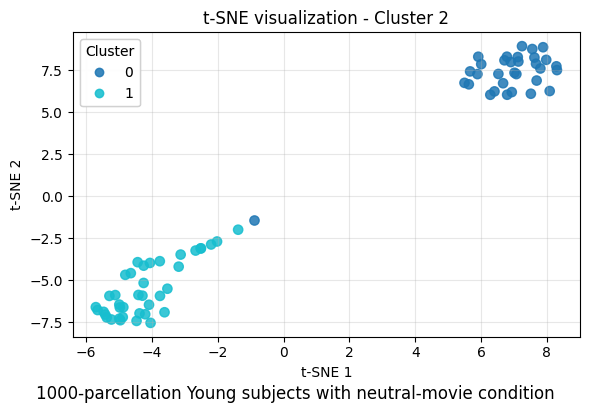

In [9]:
# T-sne for one clustering
from Evaluate_models_clean import plot_clustering

parcellation = 1000
Age = "Y"
run = 1

if Age == "Y":
    n_subjects = 71
    Age_name = "Young"
elif Age == "O":
    n_subjects = 68
    Age_name = "Old"

ids = f"{parcellation}x{parcellation}_{n_subjects}_{Age}_subjects_run{run}_cluster_"
cluster_number = 2

if run == 1:
    movie = "neutral"
elif run == 2:
    movie = "negative"

labels_path = f"Clusters\\DCEC_{ids}{cluster_number}_labels_predicted_labels_.txt"
middle_layer_path = f"Clusters\\DCEC_{ids}{cluster_number}_middle_layer_predicted_labels_.txt"
save_path = f"Figures\\Clustering results t-SNE visualization\\DCEC_{ids}{cluster_number}_clustering_plot.png"

figtext = f"{parcellation}-parcellation {Age_name} subjects with {movie}-movie condition"
title = f"t-SNE visualization - Cluster {cluster_number}"

temp_results = plot_clustering(labels_path=labels_path, middle_layer_path=middle_layer_path, save_path=save_path, title=title, figtext=figtext)

### K-means

In [16]:
# Do the K-means on the latent space of the pretrained model
from Convolutional_AE import DCEC, pretrain_cae, initialize_cluster_centers, train_dcec, predict_soft_assignments
from torch.utils.data import TensorDataset, DataLoader
from copy import deepcopy
from data_loader import set_seed
import numpy as np

# ----------------------------------------------------------
# DCEC - Deep Convolutional Embedded Clustering - Training
# ----------------------------------------------------------

set_seed(42)  # Set a fixed random seed for reproducibility

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=8, shuffle=False) # Batch_size 8 gives 9 bacthes for 71 subjects. 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cluster_sizes =  list(range(2, 11)) # Example cluster sizes to evaluate

for n_clusters in cluster_sizes:
    run_cfg = deepcopy(cfg)  # Create a copy of the config for each run
    run_cfg.n_clusters = n_clusters
    
    model = DCEC(cfg=run_cfg).to(device)
    print(f"Running K-means for cluster {n_clusters} ...")
    
    # Load the pre-trained model weights
    model.load_state_dict(torch.load(f"Models\\pre_trained_model_{cfg.name}_Cluster_{n_clusters}.pt"))  # Load the pre-trained model weights
    k_clusters, middle_layer = initialize_cluster_centers(model, dataloader, device)
    print("Early cluster centers initialized.", k_clusters)

    # Save the clusters
    print(f"Saving K-means labels for cluster {n_clusters} ...")
    np.savetxt(f"Clusters\\{cfg.name}_cluster_{n_clusters}_kmeans_labels_predicted_labels.txt", k_clusters, fmt='%d')
    np.savetxt(f"Clusters\\{cfg.name}_cluster_{n_clusters}_kmeans_middle_layer_predicted_labels.txt", middle_layer, fmt='%.6f')
    


Running K-means for cluster 2 ...
Early cluster centers initialized. [1 1 1 1 1 0 0 1 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0 1 1 1 1 0 1 0 0 1 1 0 1
 0 0 0 1 0 1 0 0 0 0 0 0 0 1 1 0 1 1 1 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 1]
Saving K-means labels for cluster 2 ...
Running K-means for cluster 3 ...
Early cluster centers initialized. [2 0 2 0 0 0 1 0 0 1 1 0 0 1 0 1 0 1 2 1 2 1 0 1 1 0 0 0 2 0 0 0 1 2 2 0 2
 1 1 1 0 1 0 1 1 1 1 0 1 1 0 0 1 0 0 0 1 0 0 1 1 1 0 1 1 0 1 1 1 1 1 0]
Saving K-means labels for cluster 3 ...
Running K-means for cluster 4 ...
Early cluster centers initialized. [2 0 2 0 0 3 1 3 3 3 1 3 3 1 0 1 3 3 2 3 2 1 3 1 1 0 0 0 2 3 0 3 1 2 2 3 2
 3 1 1 0 1 0 1 1 1 1 3 1 3 0 0 1 0 0 0 1 3 0 1 3 1 0 1 3 0 1 1 1 3 3 0]
Saving K-means labels for cluster 4 ...
Running K-means for cluster 5 ...
Early cluster centers initialized. [0 0 0 0 0 4 2 0 4 4 3 4 4 1 0 2 4 4 0 3 0 2 1 1 2 0 4 0 0 4 0 4 2 0 0 4 0
 1 2 3 0 2 4 1 2 3 1 4 3 4 2 0 3 0 0 0 1 4 0 2 4 1 0 3 1 0 3 3 3 1 1 0]
Saving K-means l

Plot saved to: Figures\Clustering Scores Plot\DCEC_400x400_71_Y_subjects_run1_k_means_clustering_scores_plot.png


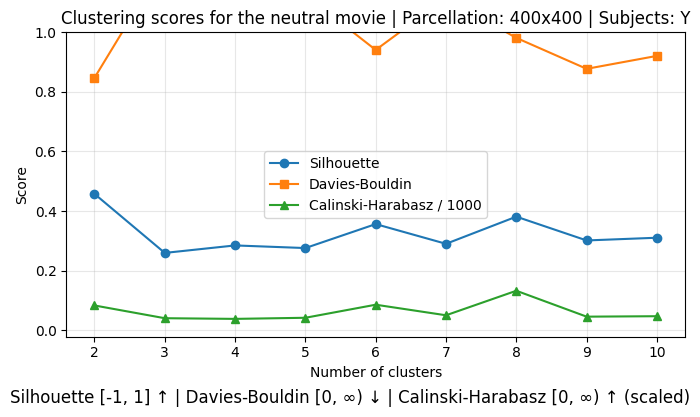

In [15]:
# Print the clustering scores for all the runs 
from Evaluate_models_clean import plot_clustering_scores_sorted

model_dir = "Clusters"
model_prefix = "DCEC_400x400_71_Y_subjects_run1_"
save_path = rf"Figures\Clustering Scores Plot\{model_prefix}k_means_clustering_scores_plot.png"

labels_tag = "kmeans_labels_predicted_labels"
middle_layer_tag = "kmeans_middle_layer_predicted_labels"

# Silhouett score: Higher is better
# Calinski-Harabasz score: Lower is better
# Davies-Bouldin score: Higher is better
temp_results = plot_clustering_scores_sorted(
    models_dir=model_dir,
    model_prefix=model_prefix,
    labels_tag=labels_tag,
    middle_layer_tag=middle_layer_tag,
    save_path=save_path,
    annotate_points=False,
    figsize=(7, 4)
    )

### Evaluate clustering against behavioural data

In [ ]:
from data_loader import load_whole_behavioural_data, combine_cca_mlr_pipeline_outputs, convert_numpy
from Evaluate_clusterings_with_CCA import full_cca_selection_subject_pipeline
from Evaluate_clusterings_with_MLR import full_mlr_selection_subject_pipeline
import json

# Load data
#csv_path = "C:\\Users\\oddar\\Downloads\\Beh.csv"
#csv_path = "C:\\Users\\oddafo\\Downloads\\Combined_Beh_Cognitive.csv"
csv_path = "Dummy Test Data\Combined_Beh_Cognitive.csv"

used_ids_path = "Dummy Test Data\\Included_subjects_Old.csv"
cluster_labels_path = "Clusters\\DCEC_400x400_68_O_subjects_run1_" # Prefix for the cluster labels files

df, included_variables = load_whole_behavioural_data(csv_path=csv_path, included_ids_path=used_ids_path, cluster_labels_path=cluster_labels_path)

# Define parameters
cluster_col = ""
subject_id_col = "Subject"
Old_run1_output_dict = {}
no_subjects = df.shape[0]

for cluster in range(2, 11):
    cluster_col = f"Cluster_{cluster}"
    n_splits = 5
    
    # Check if the current clustering is flat
    n_unique = df[cluster_col].dropna().nunique()
    if n_unique < 2:
        print(f"\n\n=== Skipping {cluster_col} due to insufficient unique clusters (n={n_unique}) ===")
        Old_run1_output_dict[cluster_col+"_results"] = {
            "cca_removed_subjects_results": {
                "mean_correlation": None,
                "removed_subjects": None
            },
            "mlr_removed_subjects_results": {
                "mean_accuracy": None,
                "removed_subjects": None
            }
        }
        continue
    
    # Check if the current clustering contains too small clusters
    cluster_counts = df[cluster_col].dropna().value_counts()
    min_cluster_size = cluster_counts.min()
    if min_cluster_size < 2 and cluster_col == "Cluster_2": 
        print(f"\n\n=== Skipping {cluster_col} due to small cluster size (min cluster size={min_cluster_size}) ===")
        Old_run1_output_dict[cluster_col+"_results"] = {
            "cca_removed_subjects_results": {
                "mean_correlation": None,
                "removed_subjects": None
            },
            "mlr_removed_subjects_results": {
                "mean_accuracy": None,
                "removed_subjects": None
            }
        }
        continue

    n_splits = max(min(n_splits, min_cluster_size), 3)  # Adjust n_splits based on the smallest cluster size

    print(f"\n\n=== Running pipelines for {cluster_col} ===")
    # Run pipelines
    print("Running CCA pipeline...")
    pipeline_output_cca = full_cca_selection_subject_pipeline(
        data=df,
        cluster_col=cluster_col,
        candidate_variables=included_variables,
        cv_splits=5,
        random_state=42,
        max_variables=6,
        min_improvement=0.01,
        subject_id_col=subject_id_col,
        print_results=False
    )
    print("Running MLR pipeline...")
    pipeline_output_mlr = full_mlr_selection_subject_pipeline(
        data=df,
        cluster_col=cluster_col,
        candidate_variables=included_variables,
        cv_splits=5,
        random_state=42,
        max_variables=10,
        min_improvement=0.01,
        subject_id_col=subject_id_col,
        print_results=False
    )

    # Combine results
    print("Combining results")
    combined_results = combine_cca_mlr_pipeline_outputs(pipeline_output_cca, pipeline_output_mlr)
    print(f"MLR final results: {combined_results['mlr_removed_subjects_results']['mean_accuracy']:.4f}")

    Old_run1_output_dict[cluster_col+"_results"] = combined_results

# Save results to JSON
with open("Results\\400x400_Old_run1_cluster_behavioural_results.json", "w") as f:
    json.dump(Old_run1_output_dict, f, indent=4, default=convert_numpy)

In [ ]:
# Do a single p-test
from Evaluate_p_values import create_permutation_tests_for_selected_variables_json

from data_loader import load_whole_behavioural_data

# Load data
#csv_path = "C:\\Users\\oddar\\Downloads\\Beh.csv"
#csv_path = "C:\\Users\\oddafo\\Downloads\\Combined_Beh_Cognitive.csv"
csv_path = "Dummy Test Data\Combined_Beh_Cognitive.csv"

used_ids_path = "Dummy Test Data\\Included_subjects_Young.csv"
cluster_labels_path = "Clusters\\DCEC_400x400_71_Y_subjects_run2_" # Prefix for the cluster labels files

df, included_variables = load_whole_behavioural_data(csv_path=csv_path, included_ids_path=used_ids_path, cluster_labels_path=cluster_labels_path)

# Define parameters
cluster_col = ""
subject_id_col = "Subject"
Old_run1_output_dict = {}
no_subjects = df.shape[0]

In [ ]:
# Do a p-test on an entire results-file
from Evaluate_p_values import create_permutation_tests_for_selected_variables_json

from data_loader import load_whole_behavioural_data

# Load data
#csv_path = "C:\\Users\\oddar\\Downloads\\Beh.csv"
#csv_path = "C:\\Users\\oddafo\\Downloads\\Combined_Beh_Cognitive.csv"
csv_path = "Dummy Test Data\Combined_Beh_Cognitive.csv"

used_ids_path = "Dummy Test Data\\Included_subjects_Old.csv"
cluster_labels_path = "Clusters\\DCEC_1000x1000_68_O_subjects_run1_" # Prefix for the cluster labels files

df, included_variables = load_whole_behavioural_data(csv_path=csv_path, included_ids_path=used_ids_path, cluster_labels_path=cluster_labels_path)


perm_results, perm_summary = create_permutation_tests_for_selected_variables_json(
    data=df,
    input_json_path=f"Results\\1000x1000_Old_run1_cluster_behavioural_results.json",
    output_json_path=f"Results\\1000x1000_Old_run1_permutation_tests_selected_variables.json",
    cluster_col_template="Cluster_{k}",
    selected_variable_keys=("cca_selected_variables", "mlr_selected_variables"),
    tests=("cca", "mlr"),
    cv_splits=5,
    random_state=42,
    n_permutations=1000,
    store_null_scores=False,
    print_results=True,
)


=== Permutation tests for Cluster_2 ===

Selected-variable set: cca_selected_variables
Variables: ['dEV_neu', 'ACC', 'EnglishYearsSpeaking', 'Q3SevereDepression', 'Q1_DASSAnxiety', 'Q2_DERSSTRATEGIES']
CCA: observed=0.5743, p=0.0010


C:\Users\oddar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [2]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\oddar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [2]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


MLR: observed=0.6989, p=0.0070

Selected-variable set: mlr_selected_variables
Variables: ['Q2_DERSNONACCEPT', 'Q8personal_distress', 'dEV_neu']
CCA: observed=0.3982, p=0.0010
MLR: observed=0.7473, p=0.0010

=== Permutation tests for Cluster_3 ===

Selected-variable set: cca_selected_variables
Variables: ['Q3_GHQ28Anxiety_Insomnia', 'Q7F2']
CCA: observed=0.4815, p=0.0020
MLR: observed=0.4473, p=0.1079

Selected-variable set: mlr_selected_variables
Variables: ['Q3_GHQ28Score', 'rmet', 'Q2_DERSScore']
CCA: observed=0.4221, p=0.0020
MLR: observed=0.5516, p=0.0020

=== Permutation tests for Cluster_4 ===

Selected-variable set: cca_selected_variables
Variables: ['Q8Cog_em', 'Q7F2', 'spanForward', 'Q2_DERSAWARENESS']
CCA: observed=0.5371, p=0.0010
MLR: observed=0.2846, p=0.4316

Selected-variable set: mlr_selected_variables
Variables: ['Order', 'Relationshipstatus', 'Q7F1']
CCA: observed=0.1171, p=0.2867
MLR: observed=0.4923, p=0.0010

=== Permutation tests for Cluster_5 ===

Selected-variab

In [3]:
from Evaluate_p_values import apply_bh_fdr_to_permutation_jsons

json_paths = [
    r"Results\\400x400_Old_run1_permutation_tests_selected_variables.json",
    r"Results\\400x400_Old_run2_permutation_tests_selected_variables.json",
    r"Results\\400x400_Young_run1_permutation_tests_selected_variables.json",
    r"Results\\400x400_Young_run2_permutation_tests_selected_variables.json",
    r"Results\\1000x1000_Old_run1_permutation_tests_selected_variables.json",
    r"Results\\1000x1000_Old_run2_permutation_tests_selected_variables.json",
    r"Results\\1000x1000_Young_run1_permutation_tests_selected_variables.json",
    r"Results\\1000x1000_Young_run2_permutation_tests_selected_variables.json",
]

updated_jsons, fdr_summary = apply_bh_fdr_to_permutation_jsons(
    json_paths=json_paths,
    alpha=0.05,
    correction_scope="by_test_and_selected_variable_key",
    tests=("cca", "mlr"),
    selected_variable_keys=("cca_selected_variables", "mlr_selected_variables"),
    in_place=True, 
    make_backup=False,
    print_results=True,
)

Updated JSON in place: Results\400x400_Old_run1_permutation_tests_selected_variables.json
Updated JSON in place: Results\400x400_Old_run2_permutation_tests_selected_variables.json
Updated JSON in place: Results\400x400_Young_run1_permutation_tests_selected_variables.json
Updated JSON in place: Results\400x400_Young_run2_permutation_tests_selected_variables.json
Updated JSON in place: Results\1000x1000_Old_run1_permutation_tests_selected_variables.json
Updated JSON in place: Results\1000x1000_Old_run2_permutation_tests_selected_variables.json
Updated JSON in place: Results\1000x1000_Young_run1_permutation_tests_selected_variables.json
Updated JSON in place: Results\1000x1000_Young_run2_permutation_tests_selected_variables.json

=== Benjamini-Hochberg FDR summary ===
Correction scope: by_test_and_selected_variable_key
alpha: 0.05
Number of valid p-values: 192
Raw p <= 0.05: 140
BH-FDR significant: 134


### Plot the behavioural analysis results

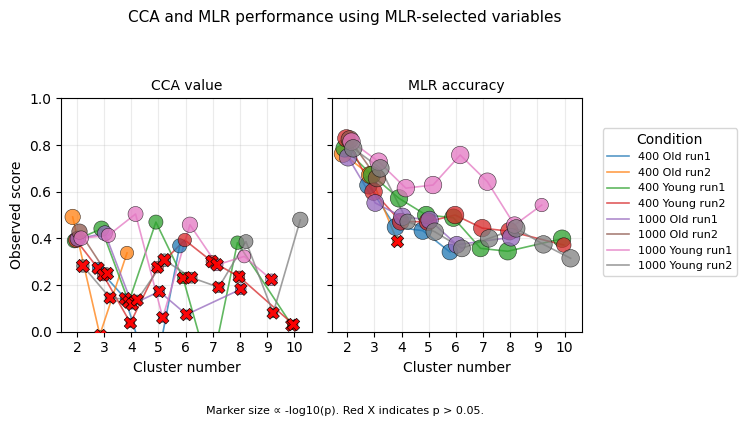

In [ ]:
from Evaluate_p_values import plot_cca_mlr_side_by_side_same_selected_variables

plot_df = plot_cca_mlr_side_by_side_same_selected_variables(
    json_paths=[
        r"Results\\400x400_Old_run1_permutation_tests_selected_variables.json",
        r"Results\\400x400_Old_run2_permutation_tests_selected_variables.json",
        r"Results\\400x400_Young_run1_permutation_tests_selected_variables.json",
        r"Results\\400x400_Young_run2_permutation_tests_selected_variables.json",
        r"Results\\1000x1000_Old_run1_permutation_tests_selected_variables.json",
        r"Results\\1000x1000_Old_run2_permutation_tests_selected_variables.json",
        r"Results\\1000x1000_Young_run1_permutation_tests_selected_variables.json",
        r"Results\\1000x1000_Young_run2_permutation_tests_selected_variables.json",
    ],
    condition_labels=[
        "400 Old run1",
        "400 Old run2",
        "400 Young run1",
        "400 Young run2",
        "1000 Old run1",
        "1000 Old run2",
        "1000 Young run1",
        "1000 Young run2",
    ],
    selected_variable_key="mlr_selected_variables",
    selected_variable_title="MLR-selected variables",
    figsize=(7, 4),
    y_lim=(0, 1),
    save_path=r"Figures\\p-values\\CCA_MLR_side_by_side_MLR_selected_variables.png",
)

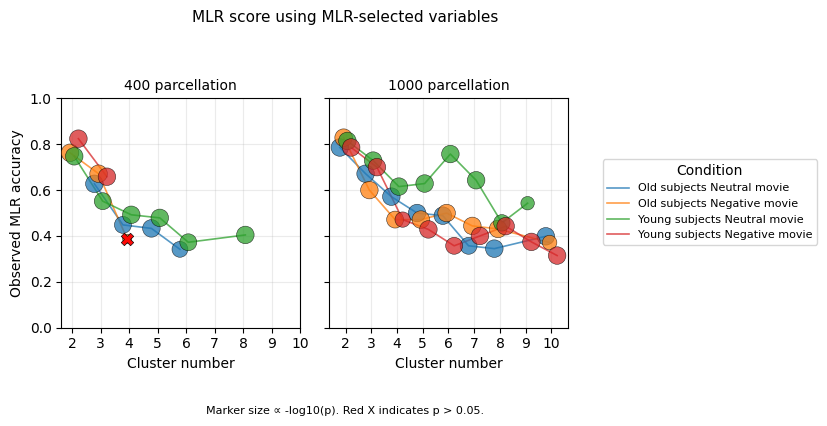

In [ ]:
from Evaluate_p_values import plot_selected_score_two_file_sets

plot_df = plot_selected_score_two_file_sets(
    left_json_paths=[
        r"Results\\400x400_Old_run1_permutation_tests_selected_variables.json",
        r"Results\\400x400_Old_run2_permutation_tests_selected_variables.json",        
        r"Results\\1000x1000_Old_run1_permutation_tests_selected_variables.json",
        r"Results\\1000x1000_Old_run2_permutation_tests_selected_variables.json",
    ],
    right_json_paths=[
        r"Results\\400x400_Young_run1_permutation_tests_selected_variables.json",
        r"Results\\400x400_Young_run2_permutation_tests_selected_variables.json",        
        r"Results\\1000x1000_Young_run1_permutation_tests_selected_variables.json",
        r"Results\\1000x1000_Young_run2_permutation_tests_selected_variables.json",

    ],
    left_title="400 parcellation",
    right_title="1000 parcellation",
    left_labels=[
        "Old subjects Neutral movie",
        "Old subjects Negative movie",
        "Young subjects Neutral movie",
        "Young subjects Negative movie",
    ],
    right_labels=[
        "Old subjects Neutral movie",
        "Old subjects Negative movie",
        "Young subjects Neutral movie",
        "Young subjects Negative movie",
    ],
    score_type="mlr",
    selected_variable_key="mlr_selected_variables",
    selected_variable_title="MLR-selected variables",
    figsize=(7, 4),
    y_lim=(0, 1),
    save_path=r"Figures\\p-values\\MLR_MLR_selected_old_vs_young.png",
)

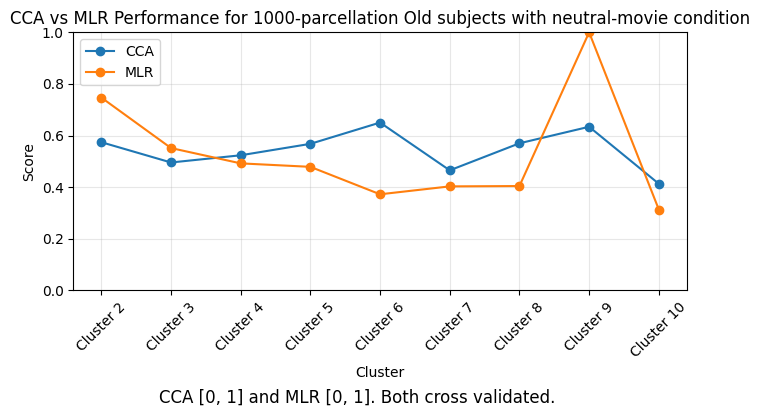

In [8]:
from Evaluate_models_clean import plot_cca_mlr_across_clusters

parcellation = 1000
Age = "O"
run = 1

if Age == "Y":
    n_subjects = 71
    Age_name = "Young"
elif Age == "O":
    n_subjects = 68
    Age_name = "Old"

ids = f"{parcellation}x{parcellation}_{n_subjects}_{Age}_subjects_run{run}_cluster_"
cluster_number = 4

if run == 1:
    movie = "neutral"
elif run == 2:
    movie = "negative"
title = f"CCA vs MLR Performance for {parcellation}-parcellation {Age_name} subjects with {movie}-movie condition"


name = f"{parcellation}x{parcellation}_{Age_name}_run{run}"
json_path = f"Results\\{name}_cluster_behavioural_results.json"
save_path = f"Figures\\CCA and MLR scores across clusters\\{name}_cluster_metric_relationship.png"

results = plot_cca_mlr_across_clusters(json_path, title=title, save_path=save_path, figsize=(7,4))

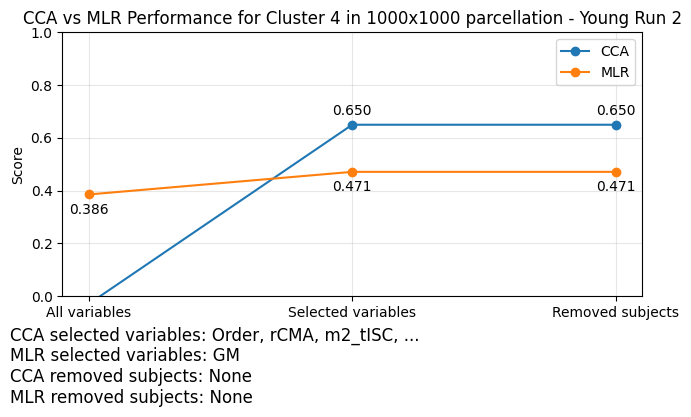

In [10]:
from Evaluate_models_clean import plot_single_cluster_cca_mlr_variants

parcellation = 1000
Age = "Y"
run = 2

if Age == "Y":
    n_subjects = 71
    Age_name = "Young"
elif Age == "O":
    n_subjects = 68
    Age_name = "Old"

ids = f"{parcellation}x{parcellation}_{n_subjects}_{Age}_subjects_run{run}_cluster_"
cluster_number = 4

if run == 1:
    movie = "neutral"
elif run == 2:
    movie = "negative"
title = f"CCA vs MLR Performance for {parcellation}-parcellation {Age_name} subjects with {movie}-movie condition - Cluster {cluster_number}"

json_path = f"Results\\{parcellation}x{parcellation}_{Age_name}_run{run}_cluster_behavioural_results.json"
title = f"CCA vs MLR Performance for Cluster {cluster_number} in {parcellation}x{parcellation} parcellation - {Age_name} Run {run}"
save_path = f"Figures\\CCA and MLR scores for best cluster\\{parcellation}x{parcellation}_{Age_name}_run{run}_cluster_{cluster_number}_metric_relationship.png"

results = plot_single_cluster_cca_mlr_variants(json_path=json_path, cluster_number=cluster_number, title=title, figsize=(7, 4),save_path=save_path)

In [28]:
# Compare the common variables and removed subjects across clusters
from Evaluate_models_clean import compare_common_across_clusters, print_comparison_summary

file_id = "1000x1000_Young_run2"
json_path = rf"Results\\{file_id}_cluster_behavioural_results.json"
variable_keys = ["cca_selected_variables", "mlr_selected_variables"]
removed_subjects_keys = ["cca_removed_subjects", "mlr_removed_subjects"]


results_across_clusters = compare_common_across_clusters(json_path=json_path, variable_keys=variable_keys, removed_subjects_keys=removed_subjects_keys)

save_path = rf"Figures\Common variables and removed subjects - Across clusters\{file_id}_comparison_summary.txt"
print_comparison_summary(results_across_clusters, save_path=save_path)


Comparison across clusters in: Results\\1000x1000_Young_run2_cluster_behavioural_results.json
Variable keys: ['cca_selected_variables', 'mlr_selected_variables']
Removed-subject keys: ['cca_removed_subjects', 'mlr_removed_subjects']

Common variables:
[]

Top 5 variable counts:
Order: 6
Q1_DASSAnxiety: 5
hd_negative: 5
Q5CD_RISC: 4
Q8empathic_concern: 3

Common removed subjects:
[11050, 11111, 11141, 11197]

Top 5 removed subject counts:
11050: 1
11111: 1
11141: 1
11197: 1

Comparison result saved to: Figures\Common variables and removed subjects - Across clusters\1000x1000_Young_run2_comparison_summary.txt


In [87]:
# Compare the common variables and removed subjects across same cluster
from Evaluate_models_clean import compare_common_across_runs_same_cluster, print_comparison_summary

Age = "Old"
cluster_number = "4"  # Set this to the cluster number you want to compare across runs

json_paths = [rf"Results\\1000x1000_{Age}_run1_cluster_behavioural_results.json", rf"Results\\{Age}_run1_cluster_behavioural_results.json",  rf"Results\\{Age}_run2_cluster_behavioural_results.json"]
variable_keys = ["cca_selected_variables", "mlr_selected_variables"]
removed_subjects_keys = ["cca_removed_subjects", "mlr_removed_subjects"]

results_across_same_cluster = compare_common_across_runs_same_cluster(json_paths=json_paths, variable_keys=variable_keys, removed_subjects_keys=removed_subjects_keys, cluster_number=cluster_number)
print_comparison_summary(results_across_same_cluster)


Comparison across runs for Cluster 4
Variable keys: ['cca_selected_variables', 'mlr_selected_variables']
Removed-subject keys: ['cca_removed_subjects', 'mlr_removed_subjects']

Common variables:
[]

Top 5 variable counts:
Q8Cog_em: 2
YearsEducation: 2
ER_base: 1
Order: 1
Q1_DASSStress: 1

Common removed subjects:
[12270, 12288]

Top 5 removed subject counts:
12270: 1
12288: 1


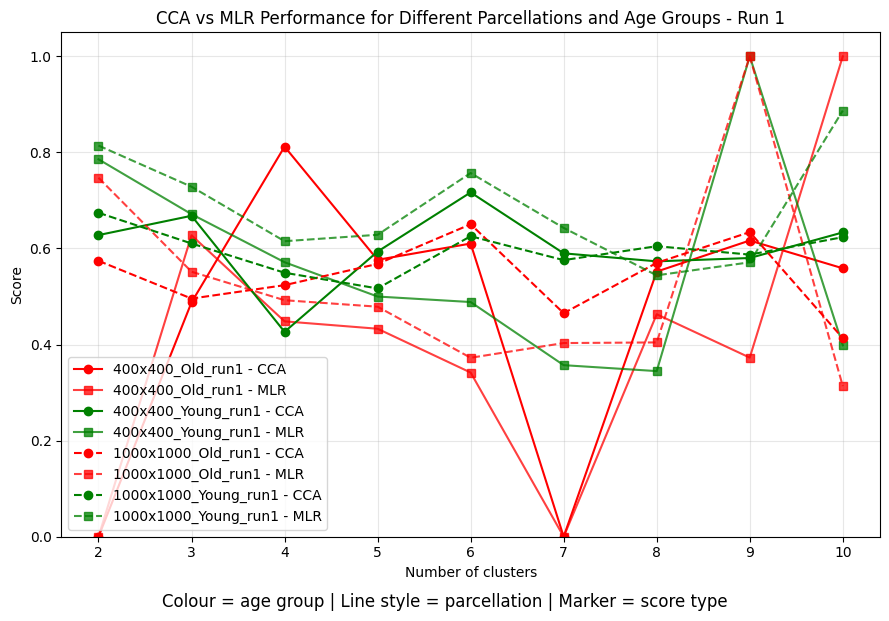

{'cluster_numbers': [2, 3, 4, 5, 6, 7, 8, 9, 10]}

In [13]:
#
from Evaluate_models_clean import plot_cca_mlr_multiple_runs

run = 1

old_400 = fr"Results\\400x400_Old_run{run}_cluster_behavioural_results.json"
young_400 = fr"Results\\400x400_Young_run{run}_cluster_behavioural_results.json"
old_1000 = fr"Results\\1000x1000_Old_run{run}_cluster_behavioural_results.json"
young_1000 = fr"Results\\1000x1000_Young_run{run}_cluster_behavioural_results.json"
list_of_json_paths = [old_400, young_400, old_1000, young_1000] 

plot_cca_mlr_multiple_runs(
    json_paths=list_of_json_paths,
    title=f"CCA vs MLR Performance for Different Parcellations and Age Groups - Run {run}",
    save_path=f"Figures\\Comparison young and old\\Comparison_parcellations_and_age_groups_run{run}.png",
    figsize=(9, 6)
    )


Skipping non-matching JSON filename: Old_run1_cluster_behavioural_results.json
Skipping non-matching JSON filename: Old_run2_cluster_behavioural_results.json
Skipping non-matching JSON filename: WRONG_1000x1000_Young_run1_cluster_behavioural_results.json
Skipping non-matching JSON filename: Young_run1_cluster_behavioural_results.json
Skipping non-matching JSON filename: Young_run2_cluster_behavioural_results.json


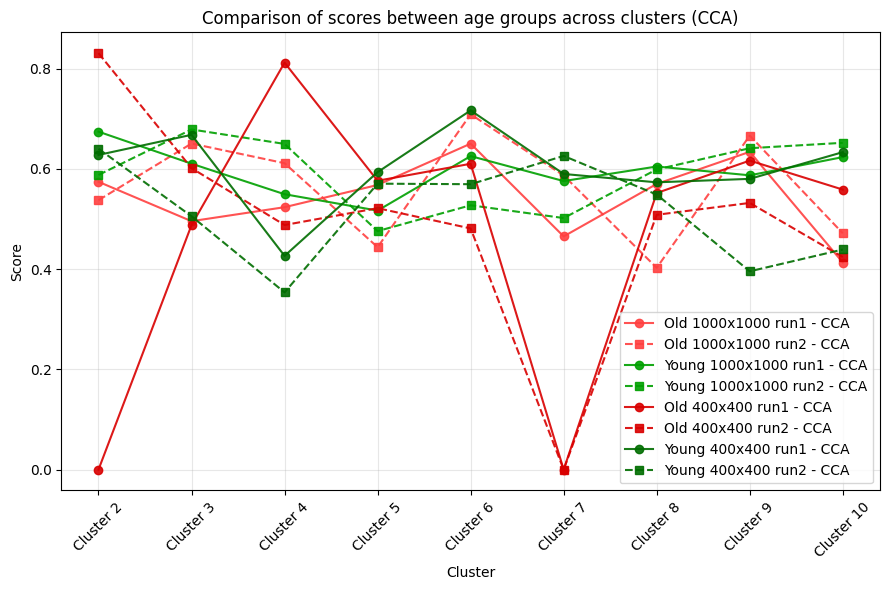

In [3]:
from Evaluate_models_clean import plot_compare_ages_across_clusters

# "mlr_removed_subjects_results:mean_accuracy"
# "cca_removed_subjects_results:cv_mean_cc"
metric_to_use = "cca_removed_subjects_results:cv_mean_cc"

save_path = rf"Figures\\Comparison young and old\\Compare_CCA_between_ages_across_clusters.png"

results = plot_compare_ages_across_clusters(metric_to_use=metric_to_use, figsize=(9,6), save_path=save_path)

Plot saved to: Figures\\Comparison young and old\\Silhouette_score_comparison_between_ages_across_clusters.png


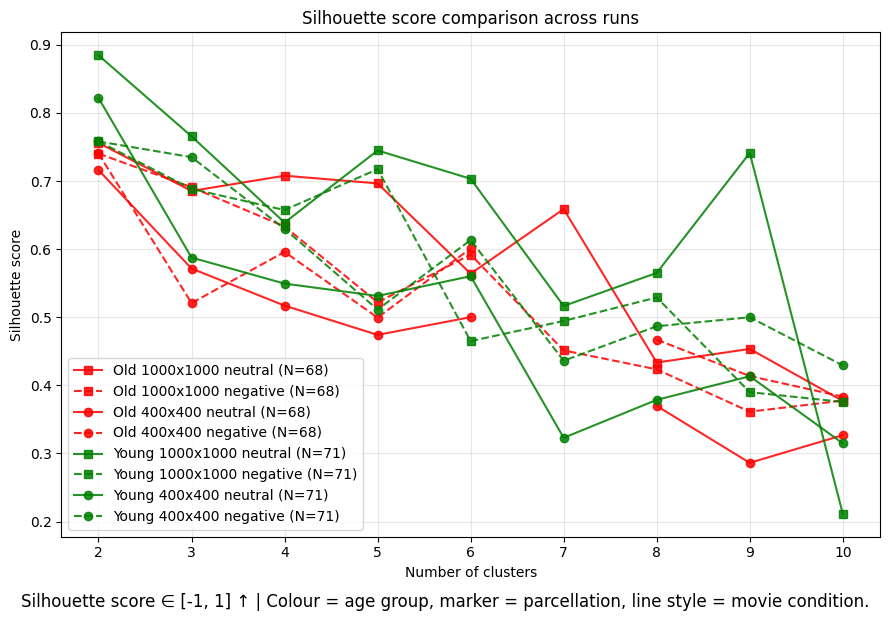

Plot saved to: Figures\\Comparison young and old\\Silhouette_score_comparison_between_parcellations_across_clusters.png


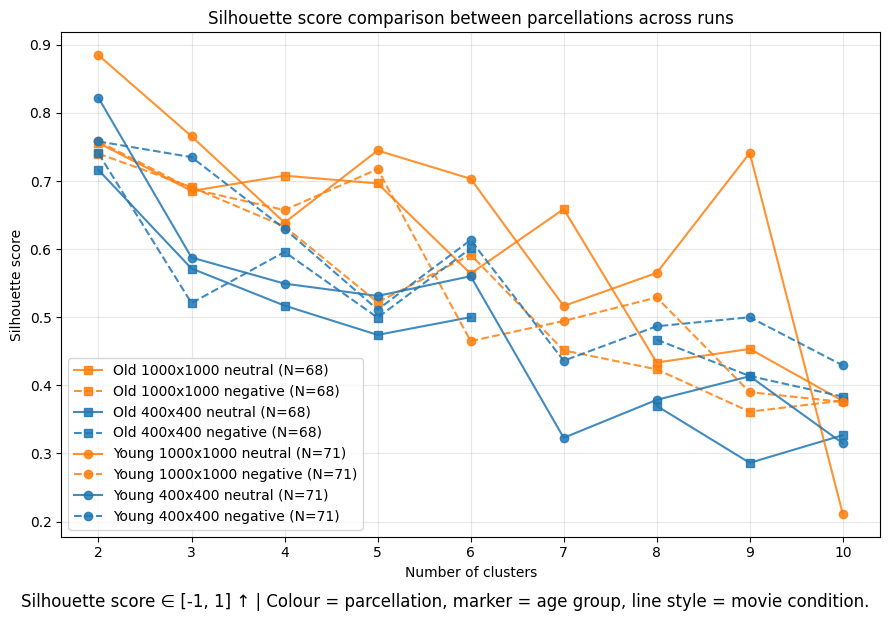

In [1]:
from Evaluate_models_clean import plot_silhouette_age_comparison_all_runs, plot_silhouette_parcellation_comparison_all_runs

models_dir = "Clusters"

save_path_age = rf"Figures\\Comparison young and old\\Silhouette_score_comparison_between_ages_across_clusters.png"
temp_results = plot_silhouette_age_comparison_all_runs(models_dir=models_dir, figsize=(9, 6), save_path=save_path_age)

save_path_parcellation = rf"Figures\\Comparison young and old\\Silhouette_score_comparison_between_parcellations_across_clusters.png"
temp_results = plot_silhouette_parcellation_comparison_all_runs(models_dir=models_dir, figsize=(9, 6), save_path=save_path_parcellation)

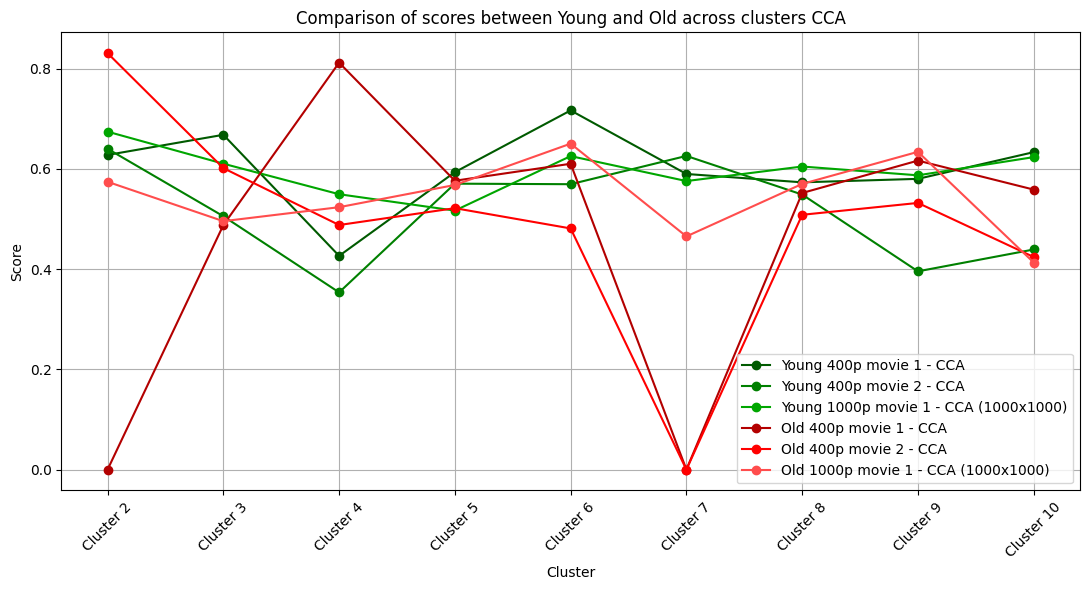

{'cluster_numbers': [2, 3, 4, 5, 6, 7, 8, 9, 10],
 'O400r1': [0.0,
  0.48794703390701943,
  0.8120525669983968,
  0.5764207844677209,
  0.6103183512914405,
  0.0,
  0.5519581167022641,
  0.6166249430511278,
  0.5587723605250307],
 'O400r2': [0.8310205852936733,
  0.6015968445404447,
  0.48807419844507427,
  0.5216988063333671,
  0.4812622121268089,
  0.0,
  0.5084803439551261,
  0.532154013993353,
  0.42424924322542257],
 'O1000r1': [0.5743221329438121,
  0.4957366260679298,
  0.523661022432494,
  0.5679871368418915,
  0.6504456465408996,
  0.46534155167222835,
  0.5700880387467463,
  0.6341344667933929,
  0.41328166627690055],
 'Y400r1': [0.6279032087059997,
  0.6681111415815162,
  0.4265257198749291,
  0.5935947258431481,
  0.7167674304150867,
  0.5899272553944713,
  0.5732729407730129,
  0.5801870655383882,
  0.6334707286438314],
 'Y400r2': [0.6401864588101673,
  0.5056009496941065,
  0.3536556199030744,
  0.5706039651853744,
  0.5695257876879533,
  0.6259530474694679,
  0.548882237

In [2]:
from Evaluate_models import plot_compare_ages_across_clusters

save_path = rf"Figures\\Comparison young and old\\Compare_CCA_between_ages_across_clusters.png"
# "mlr_removed_subjects_results:mean_aaccuracy"
# "cca_removed_subjects_results:cv_mean_cc"
metric_to_use = "cca_removed_subjects_results:cv_mean_cc"

plot_compare_ages_across_clusters(save_path=save_path, metric_to_use=metric_to_use)

In [19]:
from Evaluate_models_clean import collect_cluster_rows, summarize_grouped
from pathlib import Path

JSON_DIR = Path("Results")

# This will read all files matching your naming convention:
# {parcellation}_{age group}_{movie number}_cluster_behavioural_results.json
json_paths = sorted(JSON_DIR.glob("*_cluster_behavioural_results.json"))

rows = collect_cluster_rows(json_paths)


# Count occurrences of variables across clusters and runs
cluster_summary = summarize_grouped(rows, group_keys=["cluster"], include_second=False)

print(f"Cluster Summary:\n{cluster_summary}\n")



Skipping non-matching JSON filename: Old_run1_cluster_behavioural_results.json
Skipping non-matching JSON filename: Old_run2_cluster_behavioural_results.json
Skipping non-matching JSON filename: WRONG_1000x1000_Young_run1_cluster_behavioural_results.json
Skipping non-matching JSON filename: Young_run1_cluster_behavioural_results.json
Skipping non-matching JSON filename: Young_run2_cluster_behavioural_results.json
Cluster Summary:
   cluster  valid_cluster_solutions  \
0        2                        7   
1        3                        8   
2        4                        8   
3        5                        8   
4        6                        8   
5        7                        6   
6        8                        8   
7        9                        8   
8       10                        8   

                              most_frequent_variable  occurrences  
0                 Q2_DERSCLARITY; Q3SevereDepression            4  
1              Q3_GHQ28Anxiety_Insomnia

In [8]:
# Count occurrences shared by one movie condition group across ages
movie_summary = summarize_grouped(rows, group_keys=["movie"])
print(f"Movie Summary:\n{movie_summary}\n")

Movie Summary:
      movie  valid_cluster_solutions most_frequent_variable  occurrences  \
0  negative                       35                  Order           13   
1   neutral                       34            hd_negative           14   

          second_most_frequent_variable  second_occurrences  
0  Q3_GHQ28SomaticSymptoms; hd_negative                  11  
1                                  rmet                  10  



In [7]:
# Count occurrences shared by one age group across their runs
age_summary = summarize_grouped(rows, group_keys=["age_group"])
print(f"Age Summary:\n{age_summary}\n")

Age Summary:
  age_group  valid_cluster_solutions most_frequent_variable  occurrences  \
0       old                       33    Q8personal_distress           11   
1     young                       36            hd_negative           24   

      second_most_frequent_variable  second_occurrences  
0  ER_neg; Q3_GHQ28Anxiety_Insomnia                  10  
1                             Order                  12  



In [7]:
# Count occurrences shared by one parcellation group across their runs
parcellation_summary = summarize_grouped(rows, group_keys=["parcellation"], include_third=True)
print(f"Parcellation Summary:\n{parcellation_summary}\n")

for summary_name, summary_item in parcellation_summary.items():
    for item in summary_item:
        print(f"{summary_name}:\n{item}\n")

Parcellation Summary:
  parcellation  valid_cluster_solutions most_frequent_variable  occurrences  \
0    1000x1000                       36            hd_negative           11   
1      400x400                       33            hd_negative           14   

  second_most_frequent_variable  second_occurrences  \
0           Q8personal_distress                  10   
1                Q2_DERSCLARITY                   9   

                        third_most_frequent_variable  third_occurrences  
0  PsychDiagnosis; Q1_DASSAnxiety; Q3_GHQ28Anxiet...                  7  
1  ER_base; EV_neg; Order; Q3_GHQ28Anxiety_Insomn...                  6  

parcellation:
1000x1000

parcellation:
400x400

valid_cluster_solutions:
36

valid_cluster_solutions:
33

most_frequent_variable:
hd_negative

most_frequent_variable:
hd_negative

occurrences:
11

occurrences:
14

second_most_frequent_variable:
Q8personal_distress

second_most_frequent_variable:
Q2_DERSCLARITY

second_occurrences:
10

second_occurre

In [1]:
from Evaluate_models_clean import summarize_grouped_subjects, collect_cluster_rows
from pathlib import Path

JSON_DIR = Path("Results")
json_paths = sorted(JSON_DIR.glob("*_cluster_behavioural_results.json"))
rows = collect_cluster_rows(json_paths)
subject_summary = summarize_grouped_subjects(rows, group_keys=["cluster"])

print(f"Subject Summary:\n{subject_summary}\n")

Skipping non-matching JSON filename: Old_run1_cluster_behavioural_results.json
Skipping non-matching JSON filename: Old_run2_cluster_behavioural_results.json
Skipping non-matching JSON filename: WRONG_1000x1000_Young_run1_cluster_behavioural_results.json
Skipping non-matching JSON filename: Young_run1_cluster_behavioural_results.json
Skipping non-matching JSON filename: Young_run2_cluster_behavioural_results.json
Subject Summary:
   cluster  valid_cluster_solutions  clusters_with_removed  \
0        2                        7                      4   
1        3                        8                      4   
2        4                        8                      2   
3        6                        8                      2   
4        7                        6                      2   
5        9                        8                      2   
6       10                        8                      1   

                               most_frequent_subject  occurrences  \


In [2]:
subject_summary = summarize_grouped_subjects(rows, group_keys=["age_group"])

print(f"Subject Summary:\n{subject_summary}\n")

Subject Summary:
  age_group  valid_cluster_solutions  clusters_with_removed  \
0       old                       33                      7   
1     young                       36                     10   

        most_frequent_subject  occurrences  \
0         12127; 12288; 12334            4   
1  11073; 11074; 11103; 11201            3   

                        second_most_frequent_subject  second_occurrences  
0  12010; 12075; 12122; 12152; 12169; 12236; 1224...                   3  
1  11037; 11042; 11050; 11078; 11079; 11106; 1111...                   2  



In [4]:
subject_summary = summarize_grouped_subjects(rows, group_keys=["movie"])

print(f"Subject Summary:\n{subject_summary}\n")

Subject Summary:
      movie  valid_cluster_solutions  clusters_with_removed  \
0  negative                       35                      4   
1   neutral                       34                     13   

  most_frequent_subject  occurrences  \
0                 12127            2   
1                 12288            4   

                        second_most_frequent_subject  second_occurrences  
0  11050; 11074; 11079; 11111; 11141; 11159; 1119...                   1  
1  11073; 11103; 11201; 12122; 12152; 12242; 1227...                   3  



In [5]:
subject_summary = summarize_grouped_subjects(rows, group_keys=["parcellation"])

print(f"Subject Summary:\n{subject_summary}\n")

Subject Summary:
  parcellation  valid_cluster_solutions  clusters_with_removed  \
0    1000x1000                       36                      8   
1      400x400                       33                      9   

        most_frequent_subject  occurrences  \
0  12122; 12238; 12270; 12288            2   
1                12127; 12334            3   

                        second_most_frequent_subject  second_occurrences  
0  11020; 11024; 11050; 11073; 11074; 11103; 1110...                   1  
1  11037; 11042; 11073; 11074; 11078; 11079; 1110...                   2  

